# In-Class Activity: Logistic Regression and Support Vector Machines

In this activity, you will compare **logistic regression** and **support vector machines (SVMs)** using the Palmer Penguins dataset.

The dataset contains field measurements from penguins observed in Antarctica. We will use two bill measurements to classify penguin species and visualize how different SVM kernels change the decision boundary.

## Learning goals

By the end of this activity, you should be able to:

- Fit a logistic regression classifier.
- Fit SVM classifiers with different kernels.
- Explain why feature scaling matters for SVMs.
- Compare model performance using accuracy, confusion matrices, and classification reports.
- Visualize linear, polynomial, and radial basis function decision boundaries.

## 1. Import Packages

Run the cell below. If you are missing a package, install it before continuing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## 2. Load the Dataset

We will use the Palmer Penguins dataset. If `seaborn` cannot load the dataset on your machine, download `penguins.csv` and place it in the same folder as this notebook.

In [4]:
DATA_URL = "https://raw.githubusercontent.com/dblaskey/ML_Course_Code/main/Data/penguins.csv"

penguins = pd.read_csv(DATA_URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 3. Prepare a Binary Classification Problem

To make the decision boundaries easy to visualize, we will classify only two species:

- `Adelie`
- `Gentoo`

We will use two predictors:

- `bill_length_mm`
- `bill_depth_mm`

This is a simplified model. In a real analysis, we might use more predictors, but using two features lets us plot the decision boundary directly.

In [23]:
# Keep only two species and two numeric features
species_to_keep = ["Chinstrap", "Gentoo"]
features = ["bill_length_mm", "bill_depth_mm"]
target = "species"

penguins_binary = (
    penguins
    .loc[penguins[target].isin(species_to_keep), features + [target]]
    .dropna()
)

penguins_binary.head()

,bill_length_mm,bill_depth_mm,species
152,46.1,13.2,Gentoo
153,50.0,16.3,Gentoo
154,48.7,14.1,Gentoo
155,50.0,15.2,Gentoo
156,47.6,14.5,Gentoo


### Question 1

How many observations are in each class? Is the dataset balanced?

**Hint:** Use `value_counts()` on the target column.

In [22]:
# TODO: count the number of observations in each species class
penguins.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

## 4. Visualize the Data

Before fitting models, plot the two predictors. This helps us anticipate whether a linear boundary might work.

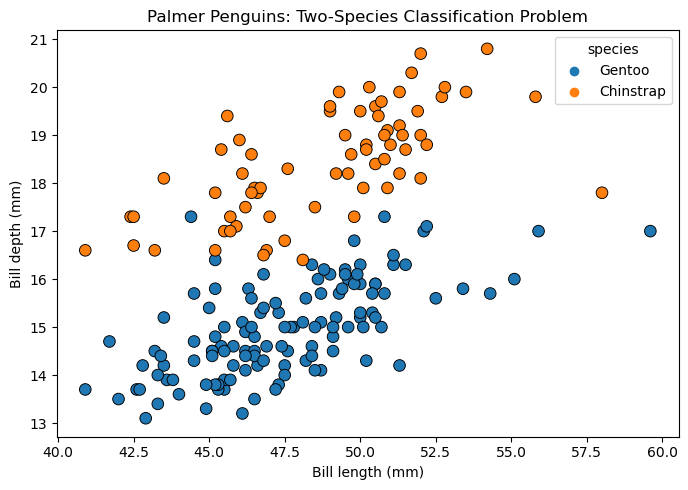

In [24]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=penguins_binary,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    s=70,
    edgecolor="black"
)

plt.title("Palmer Penguins: Two-Species Classification Problem")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.tight_layout()
plt.show()

### Question 2

Based on the scatterplot, do you expect a linear classifier to work well? Why or why not?

## 5. Train/Test Split

Now split the data into training and testing sets.

Use `stratify=y` so that both the training and testing sets preserve the class proportions.

In [ ]:
X = penguins_binary[features]
y = penguins_binary[target]

# TODO: create a train/test split
# Use test_size=0.20, random_state=33, and stratify=y

X_train, X_test, y_train, y_test = None, None, None, None

In [100]:
X = penguins_binary[features]
y = penguins_binary[target]

# TODO: create a train/test split
# Use test_size=0.25, random_state=42, and stratify=y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=33, stratify=y)

## 6. Define the Models

We will compare four classifiers:

1. Logistic regression
2. Linear SVM
3. Polynomial-kernel SVM
4. RBF-kernel SVM

SVMs are sensitive to feature scale, so each model will use a `StandardScaler()` inside a pipeline.

In [101]:
models = {
    "Logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(random_state=42))
        ]
    ),
    "Linear SVM": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", SVC(kernel="linear", C=1.0, random_state=42))
        ]
    ),
    "Polynomial SVM": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", SVC(kernel="poly", degree=3, C=1.0, random_state=42))
        ]
    ),
    "RBF SVM": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
        ]
    ),
}

## 7. Fit and Evaluate the Models

Fit each model on the training data and evaluate it on the test data.

In [102]:
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "model": model_name,
        "test_accuracy": accuracy
    })

results_df = pd.DataFrame(results)
results_df

,model,test_accuracy
0,Logistic regression,0.937500
1,Linear SVM,0.979167
2,Polynomial SVM,0.916667
3,RBF SVM,1.000000


### Question 3

Which model has the highest test accuracy? Are the differences large enough to be meaningful?

## 8. Confusion Matrices

Accuracy is useful, but it does not show which classes are being confused. Create a confusion matrix for each model.

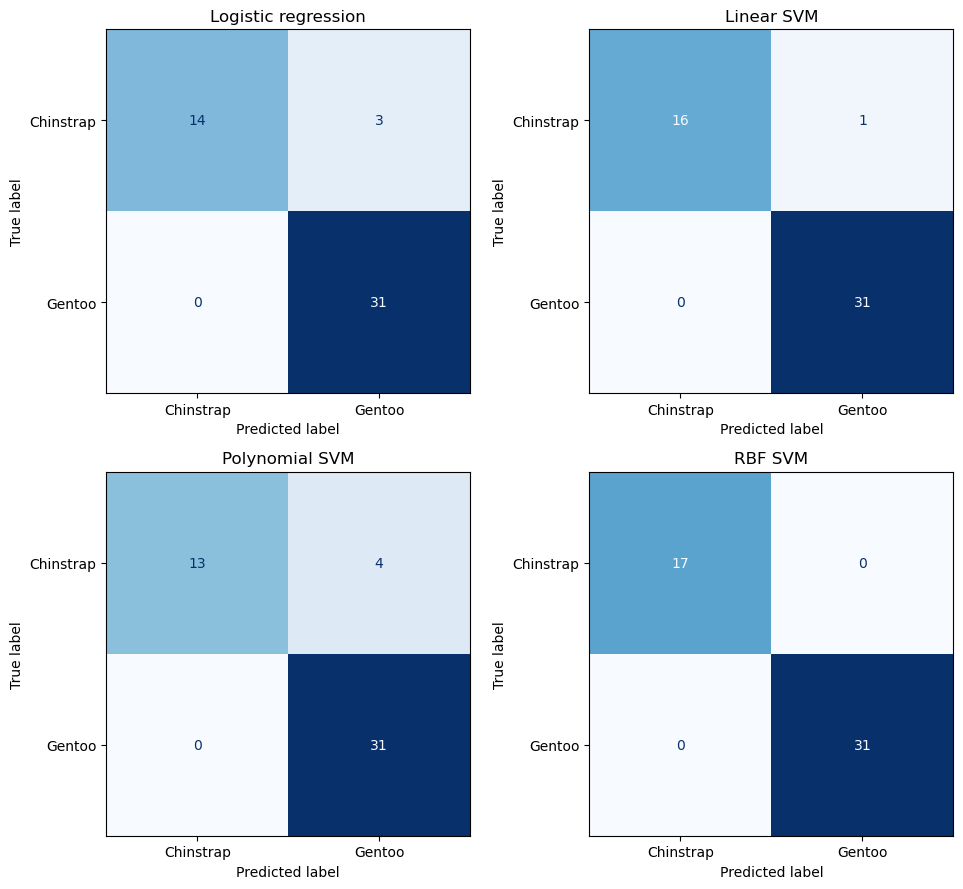

In [103]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for ax, (model_name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=species_to_keep
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=species_to_keep
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(model_name)

plt.tight_layout()
plt.show()

### Question 4

Do any models make noticeably different types of mistakes? Explain using the confusion matrices.

## 9. Classification Reports

A classification report gives precision, recall, and F1-score for each class.

In [104]:
for model_name, model in models.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

Logistic regression
              precision    recall  f1-score   support

   Chinstrap       1.00      0.82      0.90        17
      Gentoo       0.91      1.00      0.95        31

    accuracy                           0.94        48
   macro avg       0.96      0.91      0.93        48
weighted avg       0.94      0.94      0.94        48

Linear SVM
              precision    recall  f1-score   support

   Chinstrap       1.00      0.94      0.97        17
      Gentoo       0.97      1.00      0.98        31

    accuracy                           0.98        48
   macro avg       0.98      0.97      0.98        48
weighted avg       0.98      0.98      0.98        48

Polynomial SVM
              precision    recall  f1-score   support

   Chinstrap       1.00      0.76      0.87        17
      Gentoo       0.89      1.00      0.94        31

    accuracy                           0.92        48
   macro avg       0.94      0.88      0.90        48
weighted avg       0.93     

## 10. Visualize Decision Boundaries

The function below draws the classification regions learned by each model.

The color background shows the predicted class across the feature space. The points show the actual observations.

In [105]:
from matplotlib.lines import Line2D

def plot_decision_boundary(model, X_train, y_train, X_test, y_test, title):
    x_min = min(X_train.iloc[:, 0].min(), X_test.iloc[:, 0].min()) - 1
    x_max = max(X_train.iloc[:, 0].max(), X_test.iloc[:, 0].max()) + 1
    y_min = min(X_train.iloc[:, 1].min(), X_test.iloc[:, 1].min()) - 1
    y_max = max(X_train.iloc[:, 1].max(), X_test.iloc[:, 1].max()) + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = pd.DataFrame(
        np.c_[xx.ravel(), yy.ravel()],
        columns=X_train.columns
    )

    Z = model.predict(grid)
    Z_numeric = pd.Series(Z).map({"Chinstrap": 0, "Gentoo": 1}).to_numpy()
    Z_numeric = Z_numeric.reshape(xx.shape)

    plt.contourf(xx, yy, Z_numeric, alpha=0.25, cmap="coolwarm")

    sns.scatterplot(
        x=X_train.iloc[:, 0],
        y=X_train.iloc[:, 1],
        hue=y_train,
        palette={"Chinstrap": "tab:blue", "Gentoo": "tab:red"},
        edgecolor="black",
        s=60,
        marker="o",
        legend=False
    )

    sns.scatterplot(
        x=X_test.iloc[:, 0],
        y=X_test.iloc[:, 1],
        hue=y_test,
        palette={"Chinstrap": "tab:blue", "Gentoo": "tab:red"},
        edgecolor="black",
        s=110,
        marker="X",
        legend=False
    )

    legend_handles = [
        Line2D([0], [0], marker="o", color="w", label="Training data",
               markerfacecolor="gray", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="X", color="w", label="Test data",
               markerfacecolor="gray", markeredgecolor="black", markersize=9),
        Line2D([0], [0], marker="o", color="w", label="Chinstrap",
               markerfacecolor="tab:blue", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Gentoo",
               markerfacecolor="tab:red", markeredgecolor="black", markersize=8),
    ]

    plt.legend(
        handles=legend_handles,
        title="Point meaning",
        loc="best",
        frameon=True
    )

    plt.title(title)
    plt.xlabel(X_train.columns[0])
    plt.ylabel(X_train.columns[1])

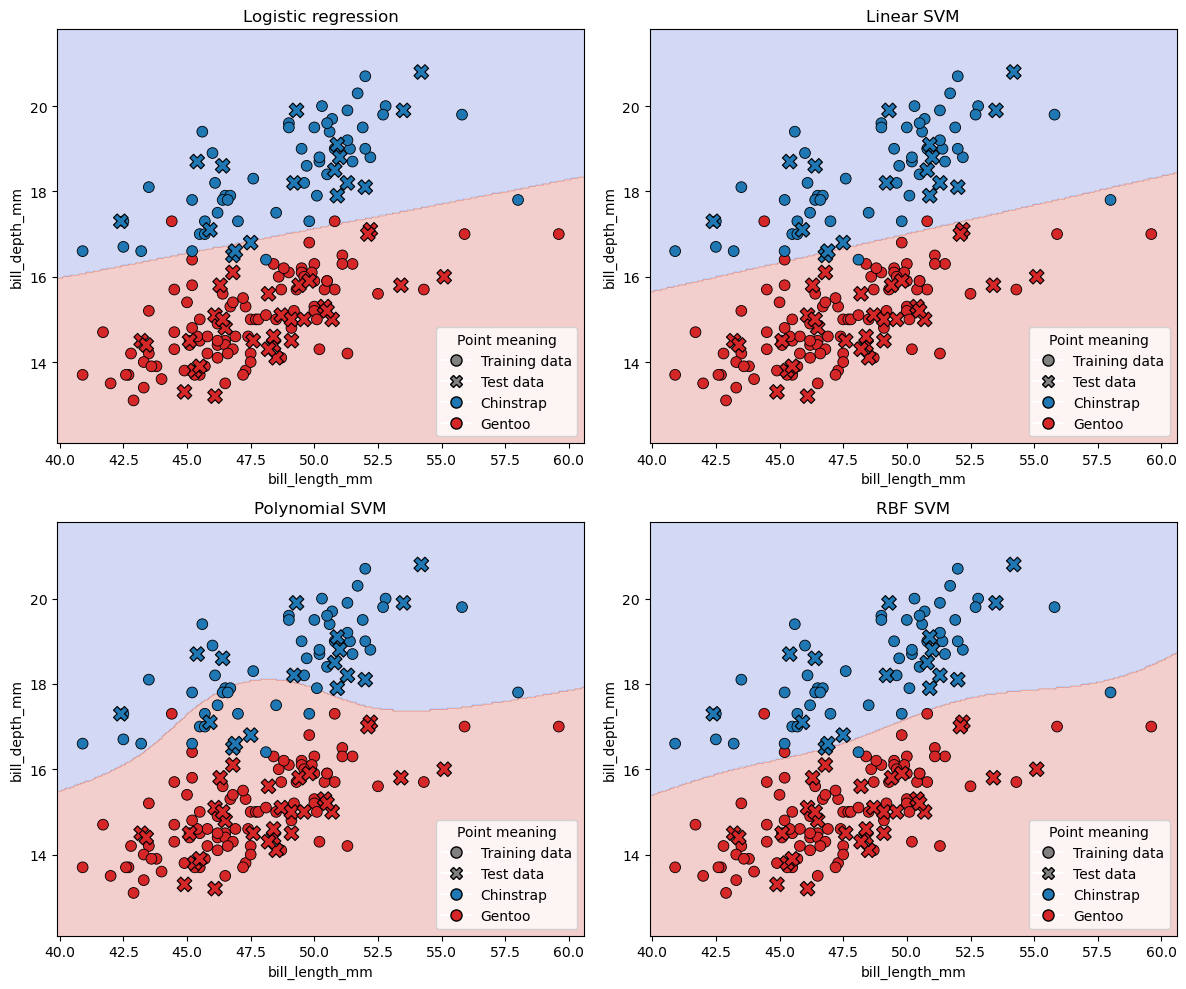

In [106]:
plt.figure(figsize=(12, 10))

for i, (model_name, model) in enumerate(models.items(), start=1):
    plt.subplot(2, 2, i)
    plot_decision_boundary(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        model_name
    )

plt.tight_layout()
plt.show()

### Question 5

Compare the decision boundaries.

- Which models produce straight decision boundaries?
- Which models produce curved decision boundaries?
- Which model seems most appropriate for this dataset?

## 11. Kernel Exploration

Now experiment with SVM settings.

Try changing:

- `C`
- `degree` for the polynomial kernel
- `gamma` for the RBF kernel

### Question 6

Choose one SVM kernel and change one parameter. What changed in the decision boundary?

**Hint:** Smaller `C` usually allows a wider margin with more tolerance for mistakes. Larger `C` tries harder to classify the training data correctly. For RBF kernels, larger `gamma` creates more local, flexible decision boundaries.

Accuracy: 1.0


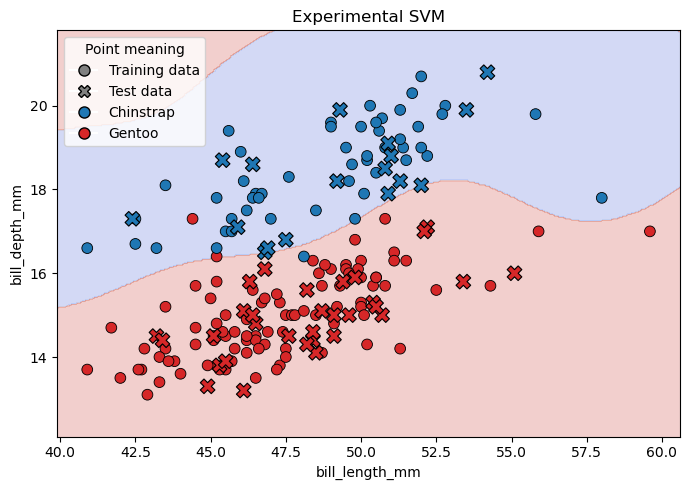

In [115]:
# TODO: modify one SVM model below and visualize its decision boundary

experiment_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", SVC(None)) # TODO
    ]
)

experiment_model.fit(X_train, y_train)

plt.figure(figsize=(7, 5))
plot_decision_boundary(
    experiment_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Experimental SVM"
)

model.fit(X_train, y_train)
y_pred = experiment_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


plt.tight_layout()
plt.show()

## 12. Reflection

Answer the following questions in a few sentences each.

1. Why do we scale predictors before fitting an SVM?
2. How is logistic regression different from a linear SVM?
3. What does the kernel do in an SVM?
4. Why might a highly flexible kernel overfit?
5. In environmental science, when might a nonlinear decision boundary be useful?
6. Where might you use SVM for classification in your research?